# SNV benchmark

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import seaborn.objects as so

custom_params = {"axes.spines.right": False, "axes.spines.top": False, "axes.edgecolor": "k"}

sns.set_theme(
    context="notebook",
    style="ticks", 
    palette="colorblind",
    font_scale=1.1,
    rc=custom_params
)

# For SVG output
plt.rcParams['svg.fonttype'] = 'none'
figdir = Path("../figures/svg")

In [2]:
base_path = Path("../analysis/array_qc/happy")

samples = pd.read_csv("../sample_info.tsv", sep="\t") 
samples["Type"] = samples["IsSingleCell"].replace({True: "Single cell", False: "Bulk"})
samples["Cell"] = "#" + samples["User ID"].str.split("_").str[-1]
# Remove for bulk samples
samples["Cell"] = samples["Cell"].str.replace("#cells", "")
human_samples = samples.query("Genome == 'Human'")
human_samples

,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type,Cell
0,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell,#01
1,P33410_1002,Q_C2_cell_02,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#02),Single cell,#02
2,P33410_1003,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#03),Single cell,#03
3,P33410_1004,Q_E2_cell_04,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#04),Single cell,#04
4,P33410_1005,Q_F2_cell_05,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#05),Single cell,#05
5,P33410_1006,Q_G2_cell_06,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#06),Single cell,#06
7,P33410_1008,Q_A3_cell_07,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#07),Single cell,#07
8,P33410_1009,Q_B3_cell_08,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#08),Single cell,#08
9,P33410_1010,Q_C3_cell_09,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#09),Single cell,#09
10,P33410_1011,Q_D3_cell_10,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#10),Single cell,#10


In [3]:
data = []

for csv in base_path.rglob("*.summary.csv"):
    print(csv)
    name = csv.parent.name
    df = pd.read_csv(
        csv, 
        header=0,
    )
    df["User ID"] = name
    df = df.query("Type == 'SNP' & Filter == 'PASS'")
    df = df.drop(["Type"], axis=1)
    data.append(df)

data = pd.concat(data).reset_index(drop=True)
data = data.merge(samples, on="User ID")
data

../analysis/array_qc/happy/B_A3_cell_01/B_A3_cell_01_vspacbio.summary.csv
../analysis/array_qc/happy/B_H3_10_cells/B_H3_10_cells_vspacbio.summary.csv
../analysis/array_qc/happy/Q_A3_cell_07/Q_A3_cell_07_vspacbio.summary.csv
../analysis/array_qc/happy/Q_C2_cell_02/Q_C2_cell_02_vspacbio.summary.csv
../analysis/array_qc/happy/B_A4_cell_02/B_A4_cell_02_vspacbio.summary.csv
../analysis/array_qc/happy/B_B2_cell_04/B_B2_cell_04_vspacbio.summary.csv
../analysis/array_qc/happy/Q_H3_10_cells/Q_H3_10_cells_vspacbio.summary.csv
../analysis/array_qc/happy/B_B4_cell_06/B_B4_cell_06_vspacbio.summary.csv
../analysis/array_qc/happy/Q_D3_cell_10/Q_D3_cell_10_vspacbio.summary.csv
../analysis/array_qc/happy/B_B3_cell_05/B_B3_cell_05_vspacbio.summary.csv
../analysis/array_qc/happy/B_B1_cell_03/B_B1_cell_03_vspacbio.summary.csv
../analysis/array_qc/happy/Q_G2_cell_06/Q_G2_cell_06_vspacbio.summary.csv
../analysis/array_qc/happy/Q_E2_cell_04/Q_E2_cell_04_vspacbio.summary.csv
../analysis/array_qc/happy/Q_D2_ce

,Filter,TRUTH.TOTAL,TRUTH.TP,TRUTH.FN,QUERY.TOTAL,QUERY.FP,QUERY.UNK,FP.gt,FP.al,METRIC.Recall,...,QUERY.TOTAL.het_hom_ratio,User ID,NGI ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type,Cell
0,PASS,165841,152186,13655,157742,5556,0,4045,280,0.917662,...,1.144807,B_A3_cell_01,P33410_1013,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#01),Single cell,#01
1,PASS,165841,153181,12660,156227,3046,0,1528,280,0.923662,...,1.200132,B_H3_10_cells,P33410_1024,False,BioSkryb,MM1S cell line,Human,BioSkryb (Bulk),Bulk,
2,PASS,165841,78151,87690,109717,31566,0,23699,227,0.471241,...,0.365539,Q_A3_cell_07,P33410_1008,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#07),Single cell,#07
3,PASS,165841,74115,91726,106750,32635,0,25055,222,0.446904,...,0.329754,Q_C2_cell_02,P33410_1002,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#02),Single cell,#02
4,PASS,165841,143367,22474,150159,6792,0,5236,257,0.864485,...,1.016938,B_A4_cell_02,P33410_1014,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#02),Single cell,#02
5,PASS,165841,133684,32157,146470,12786,0,10307,273,0.806097,...,0.895389,B_B2_cell_04,P33410_1016,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#04),Single cell,#04
6,PASS,165841,136556,29285,141022,4466,0,2795,240,0.823415,...,0.980674,Q_H3_10_cells,P33410_1012,False,Qiagen,MM1S cell line,Human,Qiagen (Bulk),Bulk,
7,PASS,165841,147519,18322,152337,4818,0,2362,268,0.889521,...,1.159920,B_B4_cell_06,P33410_1018,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#06),Single cell,#06
8,PASS,165841,61759,104082,108779,47020,0,27127,284,0.372399,...,0.530346,Q_D3_cell_10,P33410_1011,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#10),Single cell,#10
9,PASS,165841,151706,14135,155922,4216,0,2662,278,0.914768,...,1.166185,B_B3_cell_05,P33410_1017,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#05),Single cell,#05


In [26]:
data.columns

Index(['Filter', 'TRUTH.TOTAL', 'TRUTH.TP', 'TRUTH.FN', 'QUERY.TOTAL',
       'QUERY.FP', 'QUERY.UNK', 'FP.gt', 'FP.al', 'METRIC.Recall',
       'METRIC.Precision', 'METRIC.Frac_NA', 'METRIC.F1_Score',
       'TRUTH.TOTAL.TiTv_ratio', 'QUERY.TOTAL.TiTv_ratio',
       'TRUTH.TOTAL.het_hom_ratio', 'QUERY.TOTAL.het_hom_ratio', 'User ID',
       'NGI ID', 'IsSingleCell', 'Kit', 'Sample', 'Genome', 'SampleName',
       'Type', 'Cell'],
      dtype='object')

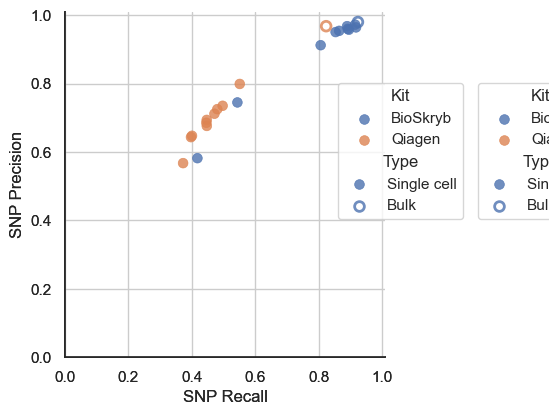

In [ ]:
fig = plt.figure(figsize=(4.8, 4.8))
p = (
    so.Plot(data, x="METRIC.Recall", y="METRIC.Precision", color="Kit", text="Cell", group="Type")
    .add(so.Dot(pointsize=7, stroke=2, alpha=0.8), fill="Type")
    .limit(x=(0, 1.01), y=(0, 1.01))
    .scale(
        color=so.Nominal(order=["PTA/ResolveDNA", "MDA/REPLI-g"]),
    )
    .layout(engine="tight")
    .label(y="SNP Precision", x="SNP Recall")
    .theme(sns.axes_style("whitegrid") | sns.plotting_context("notebook"))
    .theme(custom_params)
    .on(fig)
    .save(figdir / "snv_benchmark_array_vs_pacbio.svg", dpi=300, bbox_inches="tight", transparent=True)
)
p.show()

In [15]:
data.columns

Index(['Filter', 'TRUTH.TOTAL', 'TRUTH.TP', 'TRUTH.FN', 'QUERY.TOTAL',
       'QUERY.FP', 'QUERY.UNK', 'FP.gt', 'FP.al', 'METRIC.Recall',
       'METRIC.Precision', 'METRIC.Frac_NA', 'METRIC.F1_Score',
       'TRUTH.TOTAL.TiTv_ratio', 'QUERY.TOTAL.TiTv_ratio',
       'TRUTH.TOTAL.het_hom_ratio', 'QUERY.TOTAL.het_hom_ratio', 'User ID',
       'NGI ID', 'IsSingleCell', 'Kit', 'Sample', 'Genome', 'SampleName',
       'Type', 'Cell'],
      dtype='object')

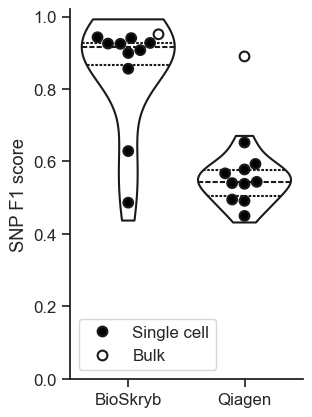

In [19]:
fig, ax = plt.subplots(figsize=(3, 4.8))
ax = sns.swarmplot(data, y="METRIC.F1_Score", x="Kit", hue="Type", palette=["black", "white"], linewidth=1.5, edgecolor="k", s=7)
ax = sns.violinplot(data.query("Type == 'Single cell'"), y="METRIC.F1_Score", x="Kit", inner="quart", fill=None, cut=0.5, density_norm="width", ax=ax, color="k")
ax.set_ylim(bottom=0)
ax.set_ylabel("SNP F1 score")
ax.set_xlabel("")
#sns.move_legend(ax, "upper left", bbox_to_anchor=(1,1))
plt.savefig(figdir / "snv_benchmark_f1_score.svg", dpi=300, bbox_inches="tight", transparent=True)

In [25]:
data.groupby(["Kit", "Type"]).agg({"METRIC.F1_Score": ["median"], "METRIC.Precision": ["median"], "METRIC.Recall": ["median"]}).reset_index()


,Kit,Type,METRIC.F1_Score,METRIC.Precision,METRIC.Recall
,,,median,median,median
0,BioSkryb,Bulk,0.951234,0.980503,0.923662
1,BioSkryb,Single cell,0.916058,0.956385,0.877003
2,Qiagen,Bulk,0.890013,0.968331,0.823415
3,Qiagen,Single cell,0.542038,0.690055,0.446991


In [ ]:
chr_lens = {}
with open("../resources/GRCh38.genome", "r") as f:
    for line in f:
        chr, length = line.strip().split("\t")
        chr_lens[chr] = int(length)

print(chr_lens)

{'chr1': 248956422, 'chr2': 242193529, 'chr3': 198295559, 'chr4': 190214555, 'chr5': 181538259, 'chr6': 170805979, 'chr7': 159345973, 'chr8': 145138636, 'chr9': 138394717, 'chr10': 133797422, 'chr11': 135086622, 'chr12': 133275309, 'chr13': 114364328, 'chr14': 107043718, 'chr15': 101991189, 'chr16': 90338345, 'chr17': 83257441, 'chr18': 80373285, 'chr19': 58617616, 'chr20': 64444167, 'chr21': 46709983, 'chr22': 50818468, 'chrX': 156040895, 'chrY': 57227415}


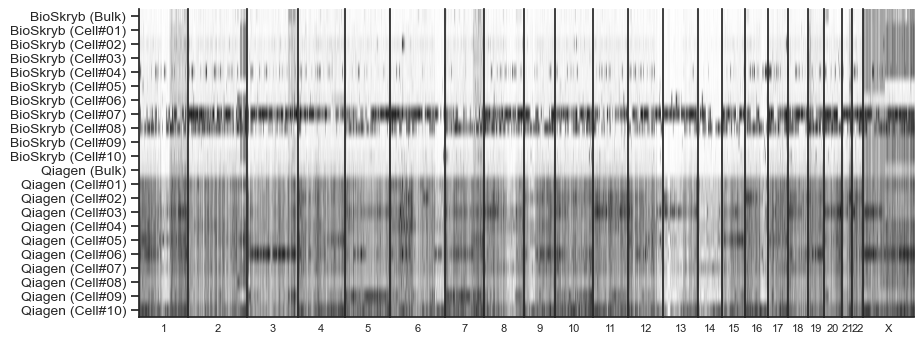

: 

In [ ]:
d = pd.read_csv(base_path / "all_fp_fn.vcf", sep="\t", header=0)
d.columns = [c if "/" not in c else c.split("/")[0] for c in d.columns ]

#d = d.apply(lambda x: x == d["Q_H3_10_cells"]).astype(int)

d["loc"] = d["chrom"] + ":" + d["start"].astype(str)
d["chrom"] = d["loc"].str.split(":", expand=True)[0]
d["pos"] = d["loc"].str.split(":", expand=True)[1]
chr_lens = d.groupby("chrom")["pos"].count().to_dict()

hs = human_samples.copy()#query("Type == 'Single cell'")
hs = hs.sort_values(["Kit", "SampleName"])
chr1toXhs = [f"chr{i}" for i in list(range(1, 23)) + ["X"]]
ratios = [chr_lens[chrom] for chrom in chr1toXhs]
ratios = [l/sum(ratios) for l in ratios]
fig, axes = plt.subplots(
    ncols=len(chr1toXhs), 
    figsize=(10,4), 
    width_ratios=ratios,
    
)
for ax, chrom in zip(axes.ravel(), chr1toXhs):
    dchrom = d.query("chrom == @chrom").copy()
    dchrom = dchrom.drop(columns=["chrom", "pos"])
    dchrom = dchrom.set_index("loc")
    dchrom = dchrom[hs['User ID']]
    #dchrom = dchrom.map(lambda x: 0)
    ax.imshow(dchrom.values.T, cmap="gray_r", aspect="auto", vmin=0, vmax=1)
    
    if chrom == "chr1":
        ax.set_yticks(range(0, dchrom.shape[1]))
        _ = ax.set_yticklabels(hs["SampleName"], fontsize=10)
    else:
        ax.set_yticks([])
    # Remove xticks
    ax.set_xticks([])
    ax.set_xticklabels([])
    
    ax.set_xlabel(chrom.replace("chr",""), fontsize=8)

fig.subplots_adjust(wspace=0)